# `Algorithm Performance Analysis`
This project analyzes sorting algorithms under different input sizes and input types to understand their real-world behavior.

In [1]:
# Importing modules:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Making the grid white
sns.set_theme(style="whitegrid")

data_path = "../data/results.csv"
# Read about os.path and how to fetch files in Python

# Loading the csv file
df = pd.read_csv(data_path)
df.head()

,Algorithm,Input_Size,Input_Type,Time_Taken,Run
0,Bubble,100,Random,0.000936,1
1,Insertion,100,Random,0.000388,1
2,Merge,100,Random,0.000214,1
3,Quick,100,Random,0.000126,1
4,Bubble,100,Sorted,0.000578,1


The above dataset contains:
1. Algorithm names
2. Input sizes (100, 500, 1000)
3. Input types (Random, Sorted, Reverse, Nearly Sorted)
4. Execution time
5. Multiple runs for stability analysis

In [5]:
# Averaging the datasets:
df_avg = df.groupby(["Algorithm", "Input_Size"])["Time_Taken"].mean().reset_index()

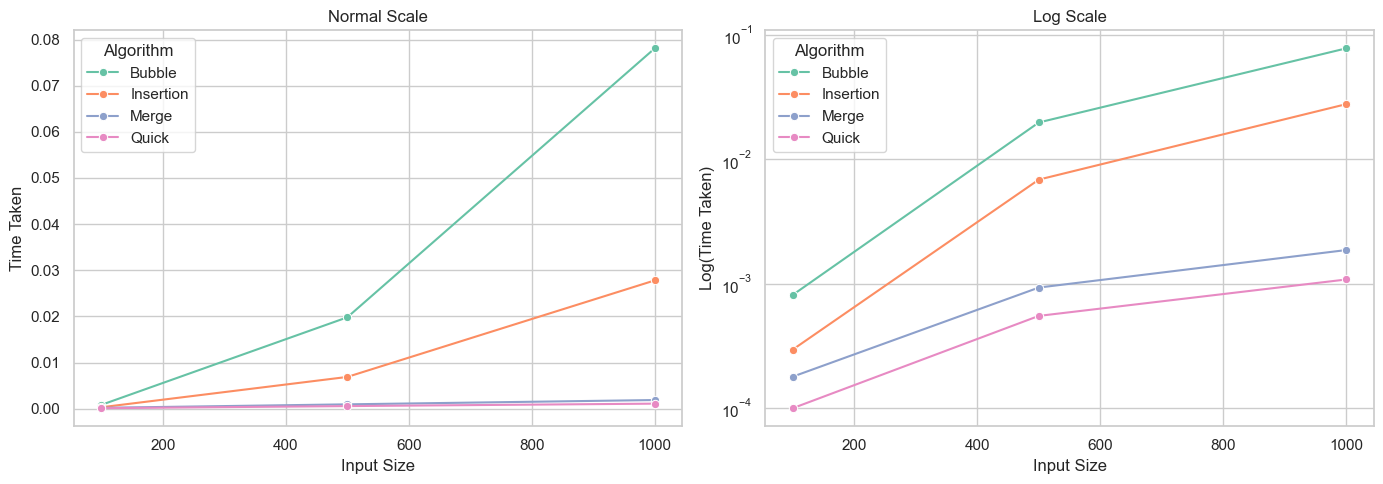

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Normal Scale
sns.lineplot(
    data=df_avg,
    x="Input_Size",
    y="Time_Taken",
    hue="Algorithm",
    marker="o",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Normal Scale")
axes[0].set_xlabel("Input Size")
axes[0].set_ylabel("Time Taken")


# RIGHT: Log Scale
sns.lineplot(
    data=df_avg,
    x="Input_Size",
    y="Time_Taken",
    hue="Algorithm",
    marker="o",
    palette="Set2",
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Log Scale")
axes[1].set_xlabel("Input Size")
axes[1].set_ylabel("Log(Time Taken)")

plt.tight_layout()
plt.show()

Observation:

- Bubble Sort shows rapid growth as input size increases, confirming O(n²) behavior.
- Insertion Sort also grows quickly but performs well on sorted data.
- Merge Sort and Quick Sort scale efficiently with input size.
- Quick Sort consistently performs slightly better than Merge Sort.
- Log scale reveals differences between fast algorithms (Merge and Quick).
- Without log scale, these differences are not clearly visible.
- This shows the importance of choosing appropriate visualization techniques.

In [9]:
# plt.figure(figsize=(10, 6))

# sns.boxplot(
#     data=df,
#     x="Algorithm",
#     y="Time_Taken",
#     hue="Algorithm", 
#     palette="Set2",
#     legend=False 
# )

# plt.title("Algorithm Performance Distribution")
# plt.xlabel("Algorithm")
# plt.ylabel("Time Taken (seconds)")

# plt.show()

In [10]:
# plt.figure(figsize=(10, 6))

# sns.boxplot(
#     data=df,
#     x="Algorithm",
#     y="Time_Taken",
#     hue="Algorithm", 
#     palette="Set2",
#     legend=False 
# )

# plt.yscale("log")

# plt.title("Algorithm Performance Distribution (Log Scale)")
# plt.xlabel("Algorithm")
# plt.ylabel("Log(Time Taken)")

# plt.show()

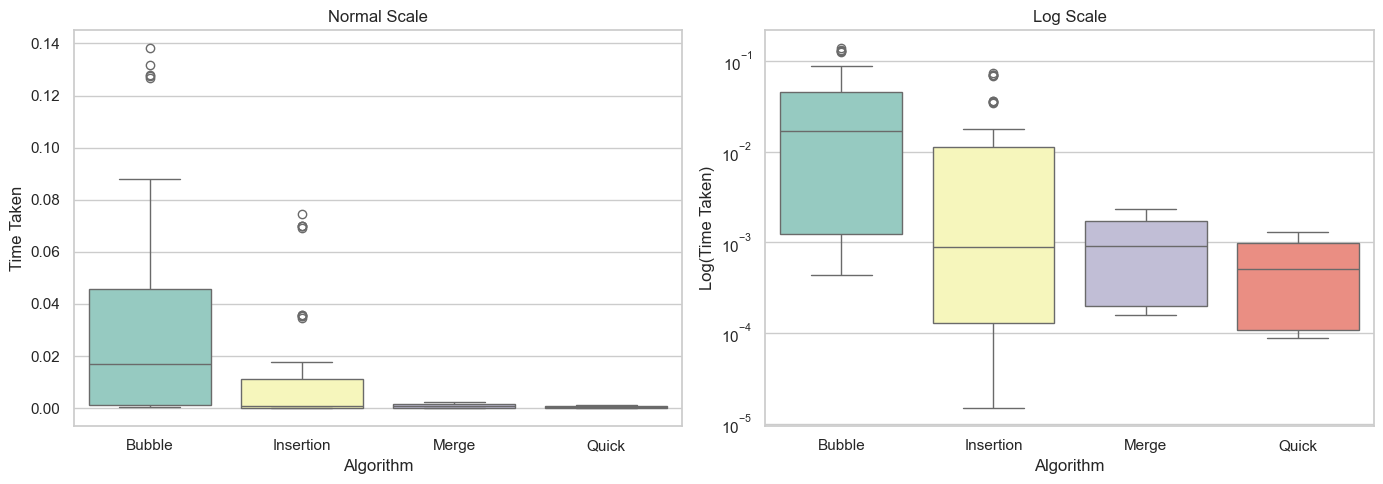

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Normal Scale
sns.boxplot(
    data=df,
    x="Algorithm",
    y="Time_Taken",
    hue="Algorithm",
    palette="Set3",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Normal Scale")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("Time Taken")


# RIGHT: Log Scale
sns.boxplot(
    data=df,
    x="Algorithm",
    y="Time_Taken",
    hue="Algorithm",
    palette="Set3",
    legend=False,
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Log Scale")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("Log(Time Taken)")

plt.tight_layout()
plt.show()

Observation:

- From the *normal scale boxplot*, **Bubble Sort** shows a very large spread in execution time, indicating high variability and poor consistency. It also has several outliers, especially at higher input sizes, which shows that its performance becomes highly unstable as data grows.

- **Insertion Sort** shows moderate variation. While it performs better than **Bubble Sort**, its execution time still fluctuates depending on the input, especially for larger datasets.

- **Merge Sort** and **Quick Sort** have very small spreads in their boxplots, indicating that they are highly stable and consistent across multiple runs. Their execution times do not vary much, even as input size increases.

- From the *log scale boxplot*, the differences between the efficient algorithms become clearer. **Merge Sort** and **Quick Sort** remain tightly grouped, confirming their predictable performance.

- **Quick Sort** appears slightly more efficient than **Merge Sort**, as its median execution time is consistently lower.

- Overall, **Bubble Sort** is the most inconsistent and least efficient, while **Merge Sort** and **Quick Sort** are both stable and efficient, with Quick Sort performing slightly better.

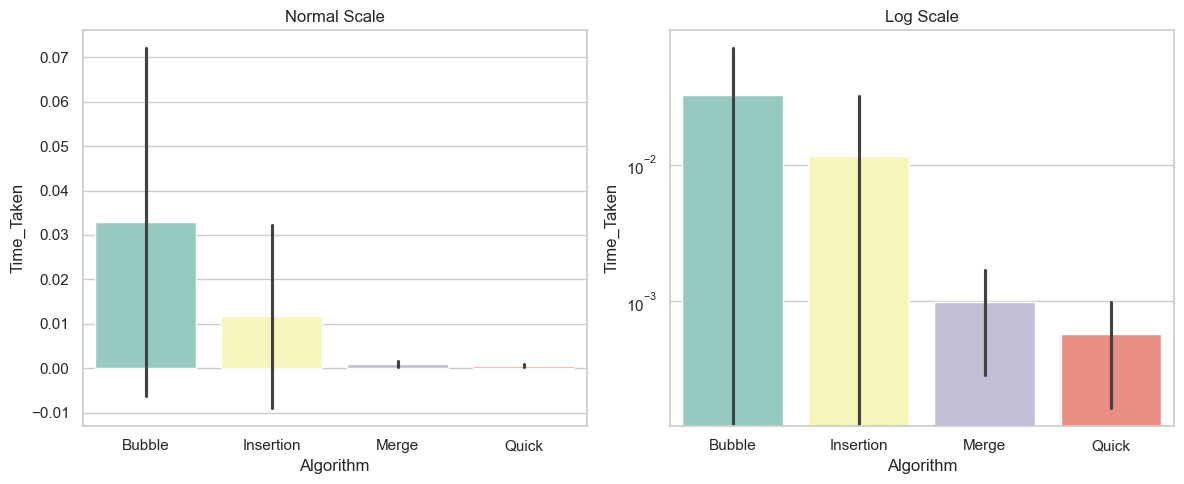

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Normal
sns.barplot(
    data=df,
    x="Algorithm",
    y="Time_Taken",
    hue="Algorithm",
    palette="Set3",
    errorbar="sd",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Normal Scale")

# Log
sns.barplot(
    data=df,
    x="Algorithm",
    y="Time_Taken",
    hue="Algorithm",
    palette="Set3",
    errorbar="sd",
    legend=False,
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Log Scale")

plt.tight_layout()
plt.show()

In [ ]:
pivot = df.groupby(["Algorithm", "Input_Size"])["Time_Taken"].mean().unstack()

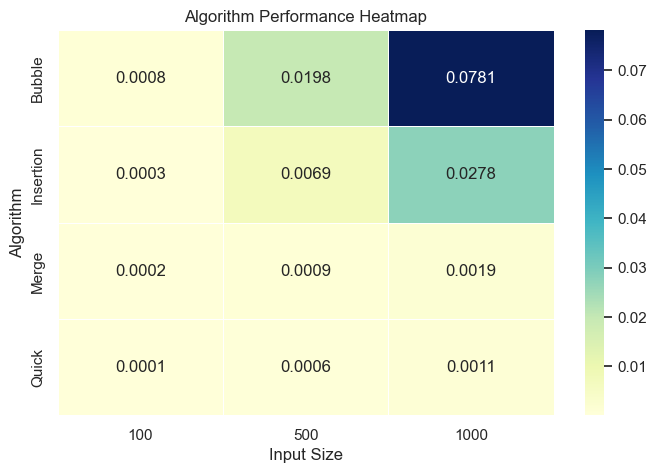

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.5,     
    linecolor="white"
)

plt.title("Algorithm Performance Heatmap")
plt.xlabel("Input Size")
plt.ylabel("Algorithm")

plt.show()

Observation:

- Bubble Sort performs poorly across all input sizes.
- Insertion Sort performs well for small and nearly sorted data.
- Merge Sort and Quick Sort consistently perform best across all sizes.
- Quick Sort is slightly faster in most cases.

Conclusion:

- Algorithm performance depends on both input size and input type.
- For small datasets, simple algorithms like Insertion Sort can be efficient.
- For larger datasets, Merge Sort and Quick Sort are significantly better.
- Quick Sort provides the best balance of speed and efficiency in most cases.

# Searching Algorithm Analysis

In [ ]:
search_df = pd.read_csv("../data/search_results.csv")
search_df.head()

,Method,Input_Size,Time_Taken,Run
0,Linear Search,100,4.375004e-06,1
1,Binary Search,100,1.750013e-06,1
2,Linear Search,100,2.541987e-06,2
3,Binary Search,100,8.329807e-07,2
4,Linear Search,100,6.332994e-06,3


In [ ]:
search_avg = search_df.groupby(["Method", "Input_Size"])["Time_Taken"].mean().reset_index()

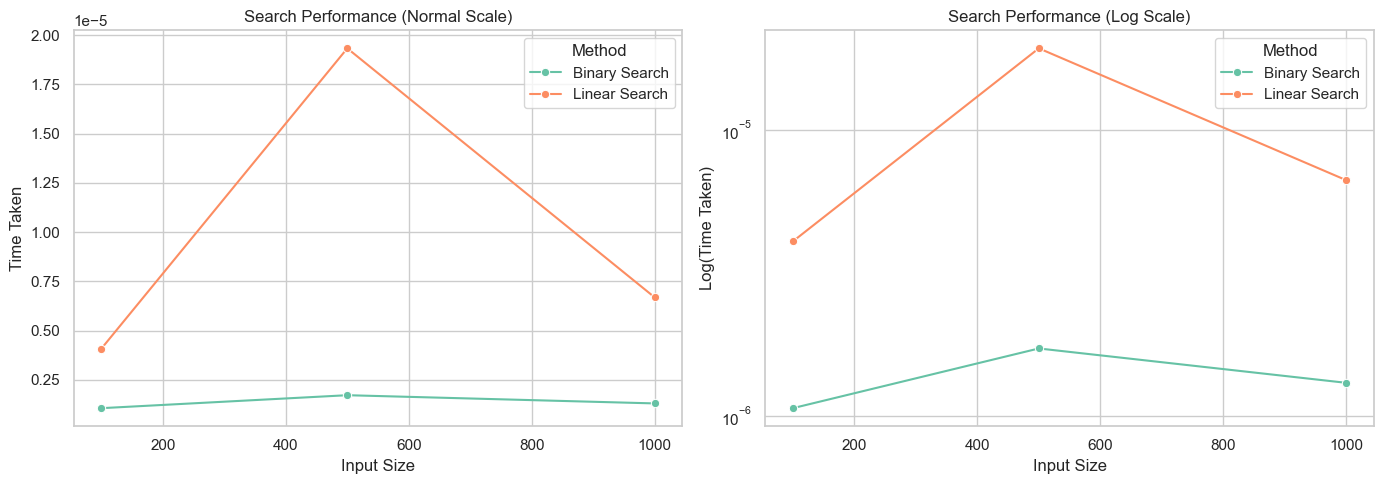

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal
sns.lineplot(
    data=search_avg,
    x="Input_Size",
    y="Time_Taken",
    hue="Method",
    marker="o",
    palette="Set2",
    errorbar=None,     
    ax=axes[0]
)

axes[0].set_title("Search Performance (Normal Scale)")
axes[0].set_xlabel("Input Size")
axes[0].set_ylabel("Time Taken")


# Log
sns.lineplot(
    data=search_avg,
    x="Input_Size",
    y="Time_Taken",
    hue="Method",
    marker="o",
    palette="Set2",
    errorbar=None,     
    ax=axes[1]
)

axes[1].set_yscale("log")
axes[1].set_title("Search Performance (Log Scale)")
axes[1].set_xlabel("Input Size")
axes[1].set_ylabel("Log(Time Taken)")

plt.tight_layout()
plt.show()

Observation:

- Binary Search performs significantly faster than Linear Search for all input sizes.
- The time taken by Binary Search grows very slowly compared to Linear Search, confirming its O(log n) complexity.
- Linear Search shows a steady increase in time as input size increases.

### Is sorting along with binary search worth?

In [ ]:
# Average sorting time (use Merge as example)
sort_avg = df[df["Algorithm"] == "Merge"].groupby("Input_Size")["Time_Taken"].mean()

# Average binary search time
binary_avg = search_df[search_df["Method"] == "Binary Search"].groupby("Input_Size")["Time_Taken"].mean()

# Combine
combined = sort_avg + binary_avg

combined_df = combined.reset_index()
combined_df["Method"] = "Sort + Binary"

# Linear search avg
linear_avg = search_df[search_df["Method"] == "Linear Search"].groupby("Input_Size")["Time_Taken"].mean().reset_index()
linear_avg["Method"] = "Linear Search"

# Merge both
final_df = pd.concat([combined_df, linear_avg])

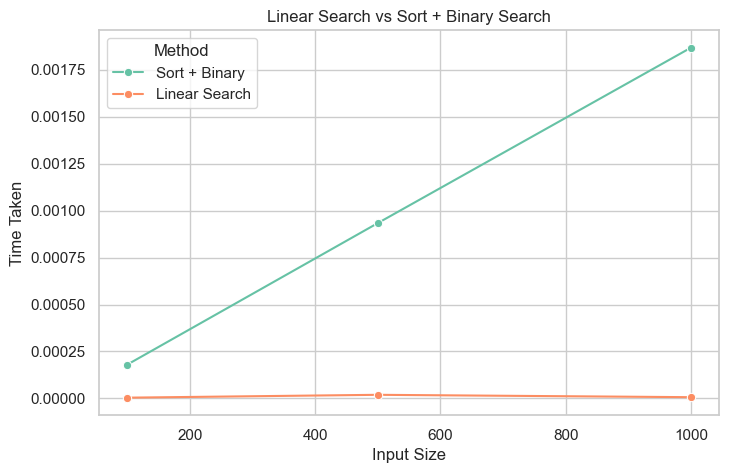

In [ ]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=final_df,
    x="Input_Size",
    y="Time_Taken",
    hue="Method",
    marker="o",
    palette="Set2"
)

plt.title("Linear Search vs Sort + Binary Search")
plt.xlabel("Input Size")
plt.ylabel("Time Taken")

plt.show()

Observation:

- For small input sizes, Linear Search performs comparably or even better since no sorting is required.
- However, as input size increases, the combined approach of sorting and then applying Binary Search becomes more efficient.
- This shows that preprocessing data (sorting) can significantly improve search performance for large datasets.
- Thus, for large-scale applications, Sort + Binary Search is a better approach than Linear Search.

- which search works best with the sorting algo?
- readme 
- after copying -> withou op -> create beautifiul readme -> what more complexity -> about columns on csv